# 01. YOLOv8 확인하기 — 사전학습 모델로 추론하고 결과 구조 이해하기

**목표**
1. COCO 사전학습 `yolov8n.pt`로 이미지를 추론한다.
2. 결과 객체(`Results`, `Boxes`)에 무엇이 들어있는지, 좌표 형식(xywh / xyxy / 정규화)이 어떻게 다른지 직접 계산해서 확인한다.
3. 시나리오에 필요한 클래스만 골라 시각화하고, 탐지 영역을 잘라(crop) 저장한다.

> 이 노트북은 과제 노트북 `3_YOLOv8_기반_제조_데이터_객체_탐지_실습` 1부를 로컬(RTX 5060)에서 다시 실행하고, 단계별 의견을 덧붙인 것이다.

In [1]:
import platform
import torch, ultralytics
print("Python", platform.python_version(), "| torch", torch.__version__, "| ultralytics", ultralytics.__version__)
print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

RUNS = "../runs/notebook01"   # 결과 이미지는 프로젝트 runs/ 아래에 저장

Python 3.11.9 | torch 2.11.0+cu128 | ultralytics 8.4.154


CUDA: True NVIDIA GeForce RTX 5060 Laptop GPU


## 1. 모델 불러오기와 추론
- `yolov8n.pt` : YOLOv8 중 가장 작은 nano 모델 (약 3.2M 파라미터). 처음 실행하면 자동 다운로드된다.
- `conf=0.25` : 신뢰도 0.25 미만의 박스는 버린다.

원본 크기 (h, w): (1080, 810)


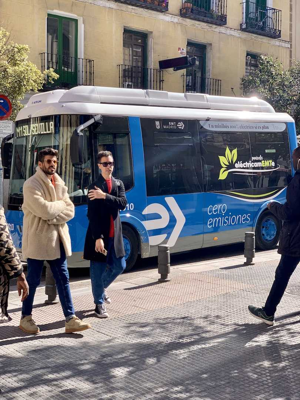

In [2]:
from io import BytesIO

import cv2
import matplotlib.pyplot as plt
import numpy as np
import requests
import yaml
from PIL import Image
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
IMG_URL = "https://ultralytics.com/images/bus.jpg"

img = Image.open(BytesIO(requests.get(IMG_URL).content)).convert("RGB")
img_np = np.array(img)
height, width = img_np.shape[:2]
print("원본 크기 (h, w):", (height, width))

thumb = img.copy(); thumb.thumbnail((400, 400)); thumb

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


image 1/1 C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 15.6ms


Speed: 48.3ms preprocess, 15.6ms inference, 20.5ms postprocess per image at shape (1, 3, 640, 480)


Results saved to C:\Users\LOQ5060\runs\runs\notebook01\predict


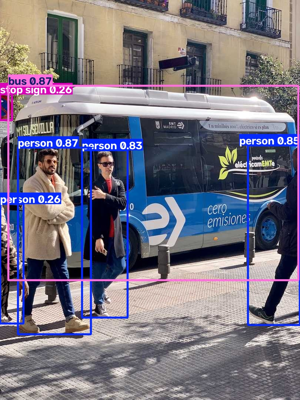

In [3]:
results = model.predict(IMG_URL, save=True, conf=0.25, project=RUNS, name="predict", exist_ok=True)
save_dir = results[0].save_dir
out = Image.open(f"{save_dir}/bus.jpg"); out.thumbnail((400, 400)); out

**의견** — 사람 4명, 버스 1대, 정지 표지판 1개를 찾았다. 왼쪽 끝에 반쯤 잘린 사람도 잡혔지만 신뢰도는 낮다(아래 `conf` 참고).

## 2. 결과 구조 살펴보기
`model.predict()`는 **이미지마다 `Results` 하나씩 담긴 리스트**를 돌려준다. 박스 정보는 `results[0].boxes`에 있다.

In [4]:
print(type(results), len(results))
print(type(results[0]))
r = results[0]
print("cls :", r.boxes.cls)
print("conf:", r.boxes.conf)

<class 'list'> 1
<class 'ultralytics.engine.results.Results'>
cls : tensor([ 5.,  0.,  0.,  0.,  0., 11.], device='cuda:0')
conf: tensor([0.8732, 0.8657, 0.8528, 0.8253, 0.2608, 0.2552], device='cuda:0')


In [5]:
# 클래스 번호 → 이름. 모델 안에도 있고(model.names), 공식 coco.yaml 에도 있다.
coco = yaml.safe_load(requests.get(
    "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml").text)
class_names = coco["names"]
print(len(class_names), "classes |", dict(list(class_names.items())[:12]), "...")
assert class_names == model.names, "모델 내장 이름과 coco.yaml 이 같다"
[(class_names[int(c)], round(float(p), 3)) for c, p in zip(r.boxes.cls, r.boxes.conf)]

80 classes | {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign'} ...


[('bus', 0.873),
 ('person', 0.866),
 ('person', 0.853),
 ('person', 0.825),
 ('person', 0.261),
 ('stop sign', 0.255)]

**의견** — COCO는 80개 클래스라 제조 현장 시나리오에는 필요 없는 클래스가 대부분이다.
→ 실제로 쓰려면 (1) 필요한 클래스만 걸러 쓰거나, (2) 내 데이터로 다시 학습해야 한다.

## 3. 좌표 형식 비교 — 직접 계산해서 확인

| 속성 | 의미 | 단위 |
|---|---|---|
| `xywh` | 중심 x, 중심 y, 너비, 높이 | 픽셀 |
| `xyxy` | 좌상단 x, y, 우하단 x, y | 픽셀 |
| `xywhn`, `xyxyn` | 위와 같음 | 0~1 (이미지 크기로 나눔) |

YOLO 학습 라벨(txt)은 **`xywhn`** 형식을 쓴다.

In [6]:
b_xywh = r.boxes.xywh[0].cpu()
manual_n = b_xywh / torch.tensor([width, height, width, height])
print("xywh        :", b_xywh)
print("직접 정규화  :", manual_n)
print("xywhn       :", r.boxes.xywhn[0].cpu())

b_xyxy = r.boxes.xyxy[0].cpu()
print("\nxyxy        :", b_xyxy)
print("직접 정규화  :", b_xyxy / torch.tensor([width, height, width, height]))
print("xyxyn       :", r.boxes.xyxyn[0].cpu())

# xywh ↔ xyxy 변환도 확인
cx, cy, w, h = b_xywh
print("\nxywh→xyxy   :", torch.tensor([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2]))

xywh        : tensor([413.9292, 494.0699, 782.1526, 525.5790])
직접 정규화  : tensor([0.5110, 0.4575, 0.9656, 0.4866])
xywhn       : tensor([0.5110, 0.4575, 0.9656, 0.4866])

xyxy        : tensor([ 22.8529, 231.2805, 805.0055, 756.8594])
직접 정규화  : tensor([0.0282, 0.2141, 0.9938, 0.7008])
xyxyn       : tensor([0.0282, 0.2141, 0.9938, 0.7008])

xywh→xyxy   : tensor([ 22.8529, 231.2805, 805.0055, 756.8594])


**의견** — 직접 계산한 값과 라이브러리 값이 일치한다. 즉 `n`이 붙은 좌표는 원본 크기로 나눈 값이라 **이미지 해상도가 바뀌어도 그대로 쓸 수 있다.**

## 4. 시각화 — 모든 박스 그리기

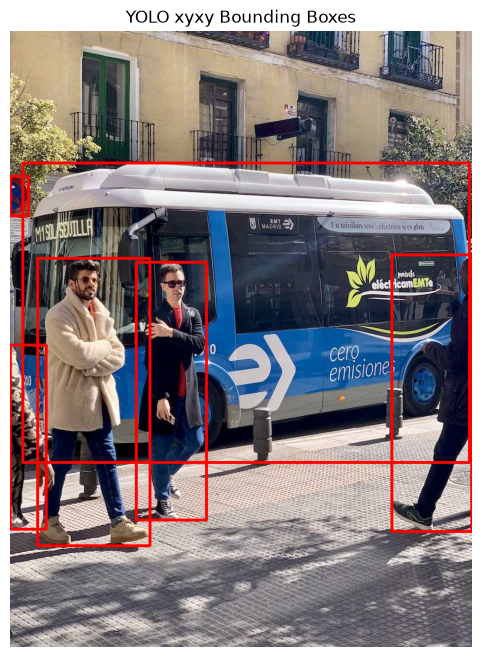

In [7]:
img_copy = img_np.copy()
for x1, y1, x2, y2 in r.boxes.xyxy.cpu().numpy().astype(int):
    cv2.rectangle(img_copy, (x1, y1), (x2, y2), color=(255, 0, 0), thickness=3)

plt.figure(figsize=(6, 8)); plt.imshow(img_copy); plt.title("YOLO xyxy Bounding Boxes"); plt.axis("off"); plt.show()

## 5. 시나리오에 필요한 클래스만 보기 — `person`
`boxes.data`는 한 줄에 `[x1, y1, x2, y2, conf, cls]`가 들어 있어서 한 번에 풀어 쓰기 좋다.

[[      22.85      231.28      805.01      756.86        0.87           5]
 [      48.55      398.55      245.34      902.71        0.87           0]
 [     669.47      392.19      809.72      877.03        0.85           0]
 [     221.51       405.8      344.97      857.55        0.83           0]
 [          0      550.52       63.04      873.44        0.26           0]
 [       0.06      254.46       32.56      324.88        0.26          11]]


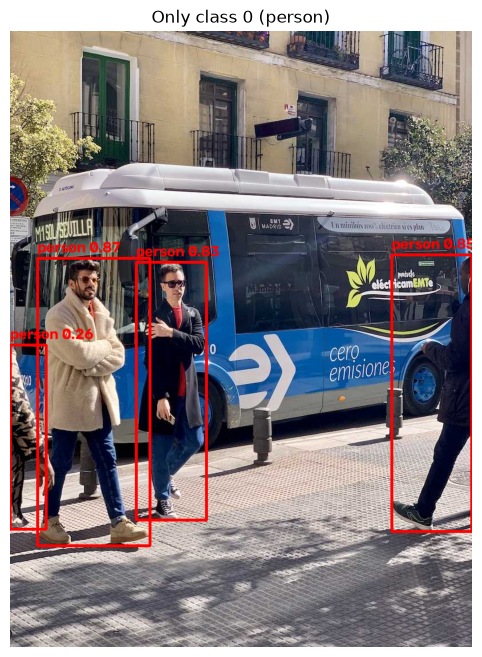

In [8]:
print(r.boxes.data.cpu().numpy().round(2))

img_copy = img_np.copy()
for x1, y1, x2, y2, conf, cls in r.boxes.data.tolist():
    if int(cls) == 0:  # person
        x1, y1, x2, y2 = map(int, (x1, y1, x2, y2))
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(img_copy, f"{class_names[int(cls)]} {conf:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
plt.figure(figsize=(6, 8)); plt.imshow(img_copy); plt.title("Only class 0 (person)"); plt.axis("off"); plt.show()

**의견** — 반쯤 가려진 사람도 찾았고, 버스는 시나리오에서 필요 없으니 시각화에서 뺐다.
시나리오가 "표지판을 찾아야 한다"라면 COCO의 `stop sign`만으로는 부족하다 → **원하는 대상을 라벨링해서 추가 학습**이 필요하다 (02 노트북).

## 6. 실험: 신뢰도 임계값(conf)에 따라 탐지 개수가 어떻게 바뀌나

In [9]:
import pandas as pd
rows = []
for c in [0.1, 0.25, 0.4, 0.55, 0.7, 0.85]:
    rr = model.predict(img_np[:, :, ::-1], conf=c, verbose=False)[0]
    names = [class_names[int(k)] for k in rr.boxes.cls]
    rows.append({"conf": c, "boxes": len(names), "person": names.count("person"),
                 "bus": names.count("bus"), "others": len(names) - names.count("person") - names.count("bus")})
pd.DataFrame(rows)

,conf,boxes,person,bus,others
0,0.10,6,4,1,1
1,0.25,6,4,1,1
2,0.40,4,3,1,0
3,0.55,4,3,1,0
4,0.70,4,3,1,0
5,0.85,3,2,1,0


**의견** — 임계값을 낮추면 잘린 사람·표지판 같은 애매한 박스가 늘고, 높이면 확실한 것만 남는다.
제조 검사에서는 **불량을 놓치면 안 되므로 불량 클래스는 임계값을 낮게**, 과검출 비용이 크면 높게 잡는 식으로 조정해야 한다.

## 7. 탐지 영역 잘라서 저장 (crop)

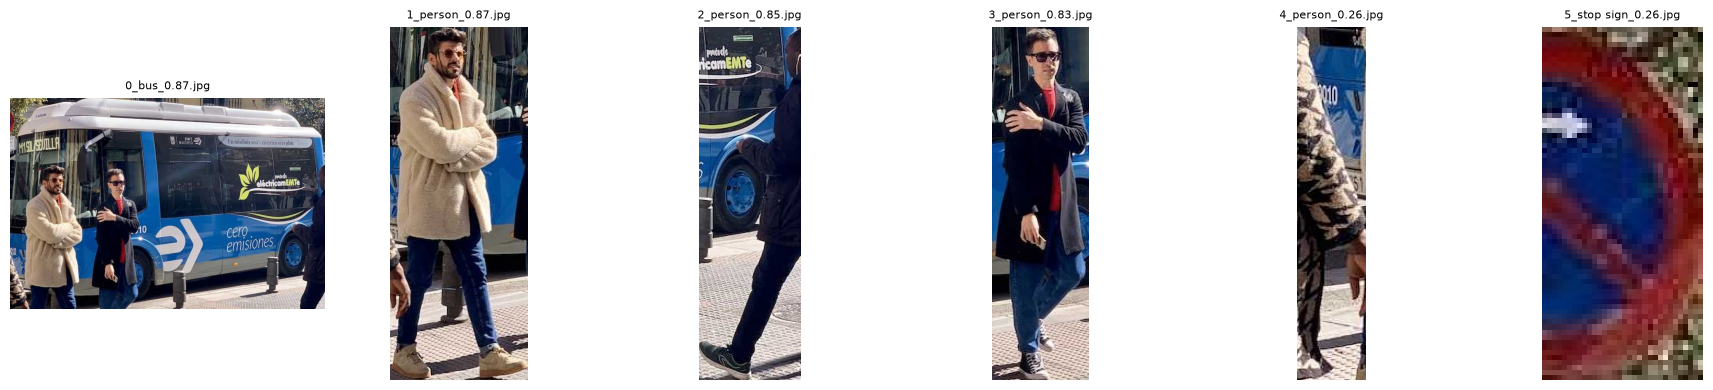

In [10]:
import os
os.makedirs("crops", exist_ok=True)
saved = []
for i, (x1, y1, x2, y2, conf, cls) in enumerate(r.boxes.data.tolist()):
    name = class_names[int(cls)]
    x1, y1, x2, y2 = map(int, (x1, y1, x2, y2))
    path = f"crops/{i}_{name}_{conf:.2f}.jpg"
    cv2.imwrite(path, cv2.cvtColor(img_np[y1:y2, x1:x2], cv2.COLOR_RGB2BGR))
    saved.append(path)

fig, axes = plt.subplots(1, len(saved), figsize=(3 * len(saved), 4))
for ax, p in zip(axes, saved):
    ax.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)); ax.set_title(os.path.basename(p), fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

**의견** — 탐지 영역을 잘라내면 이후 단계(예: 잘라낸 부품만 따로 분류·검사)에 넘길 수 있다. 제조 라인의 "탐지 → 정밀 검사" 2단계 구조의 기초가 된다.

## 정리
- `Results` → `boxes` → `xyxy / xywh / (n) / conf / cls / data` 구조를 직접 확인했다.
- 사전학습 모델은 COCO 80개 클래스만 알기 때문에, 제조 시나리오에는 **내 데이터로 학습**이 필요하다 → `02_stamp_training.ipynb`, `03_my_defect_detection.ipynb`